In [ ]:
# 1: Install Dependencies

In [1]:
# Install standard data processing, machine learning, and visualization tools
!pip install -q pandas numpy scikit-learn matplotlib seaborn openpyxl

In [ ]:
# 2: Data Ingestion and Cleanse Operation

In [3]:
import pandas as pd
import numpy as np
import datetime as dt

print("⏳ Loading transactional dataset...")
# Note: If using the Kaggle variant, change path to 'data.csv' or your specific local file name
# We use engine='openpyxl' if loading the original raw .xlsx file format
try:
    df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")
except FileNotFoundError:
    # Fallback to loading directly from standard sample frames if name differs
    print("⚠️ 'OnlineRetail.csv' not found. Please verify your filename.")

print(f"📊 Initial record volume: {df.shape[0]} rows")

# 1. Drop records lacking explicit Customer IDs (critical for structural grouping)
df = df.dropna(subset=['CustomerID'])

# 2. Convert CustomerID to standard integer format
df['CustomerID'] = df['CustomerID'].astype(int)

# 3. Cleanse Canceled Invoices (Invoice numbers beginning with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 4. Remove rows with non-positive quantities or price anomalies
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 5. Feature Engineering: Total Line Item Spend
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# 6. Parse date strings into standard DateTime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"✅ Data cleansing complete. Filtered record volume: {df.shape[0]} rows")
print(df.head(2))

⏳ Loading transactional dataset...
📊 Initial record volume: 541909 rows
✅ Data cleansing complete. Filtered record volume: 397884 rows
  InvoiceNo StockCode                         Description  Quantity  \
0    536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                 WHITE METAL LANTERN         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalSpend  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom       20.34  


In [ ]:
# 3: High-Performance RFM Feature Aggregation

In [4]:
# Create a snapshot point 1 day after the latest transaction date to measure Recency
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"🗓️ Snapshot evaluation date reference point: {snapshot_date.date()}")

# Aggregate data by CustomerID to extract behavioral attributes
print("⏳ Aggregating rows into Recency, Frequency, and Monetary (RFM) profiles...")
rfm_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency (days since last purchase)
    'InvoiceNo': 'nunique',                                  # Frequency (distinct orders)
    'TotalSpend': 'sum'                                      # Monetary Value (total expenditure)
})

# Rename columns to reflect business frameworks
rfm_df.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=True)

print(f"✅ RFM Profiles generated for {rfm_df.shape[0]} unique business consumers.")
print(rfm_df.head())

🗓️ Snapshot evaluation date reference point: 2011-12-10
⏳ Aggregating rows into Recency, Frequency, and Monetary (RFM) profiles...
✅ RFM Profiles generated for 4338 unique business consumers.
            Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             2          7   4310.00
12348            75          4   1797.24
12349            19          1   1757.55
12350           310          1    334.40


In [ ]:
# 4: Geometric Preprocessing (Log Transform & Scaling)

In [5]:
from sklearn.preprocessing import StandardScaler

# 1. Apply log transformation to manage right-skewed metric distributions
rfm_log = np.log1p(rfm_df)

# 2. Initialize StandardScaler for Z-score normalization (Mean=0, Variance=1)
scaler = StandardScaler()
scaler.fit(rfm_log)

# Transform features into a clean geometric matrix array
rfm_scaled = scaler.transform(rfm_log)

# Convert back to structured DataFrame for tracking clarity
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm_df.index, columns=rfm_df.columns)
print("✅ Log transformations and standard Z-score scaling completed successfully.")
print(rfm_scaled_df.head(2))

✅ Log transformations and standard Z-score scaling completed successfully.
             Recency  Frequency  Monetary
CustomerID                               
12346       1.461993  -0.955214  3.706225
12347      -2.038734   1.074425  1.411843


In [ ]:
# 5: Hyperparameter Optimization (Elbow Analysis & Silhouette Checks)

Matplotlib is building the font cache; this may take a moment.


⏳ Evaluating clustering configurations from k=2 through k=8...


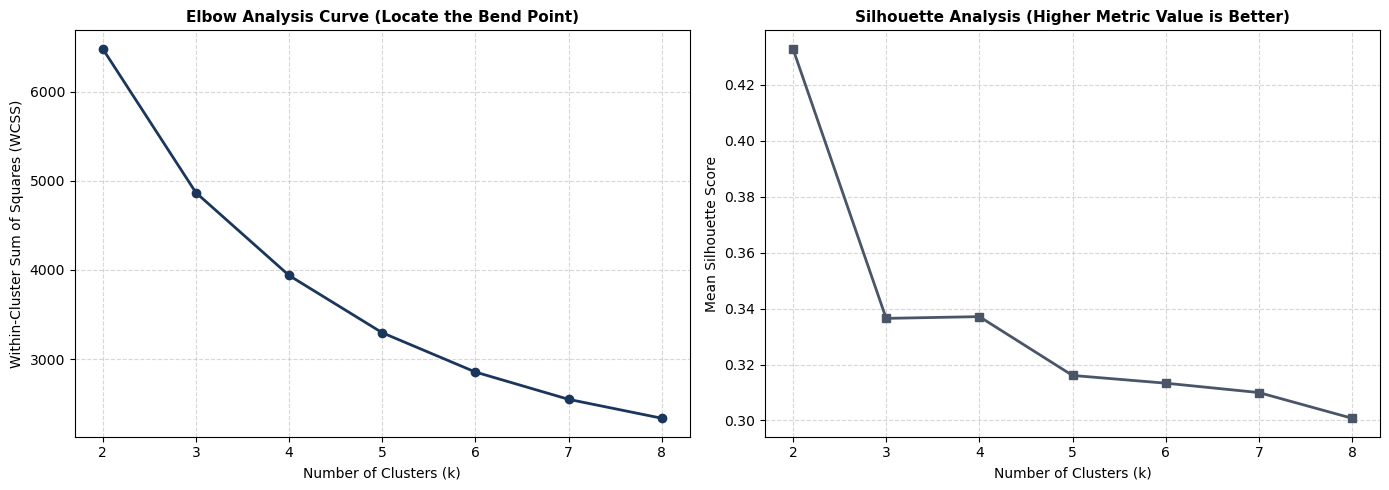

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []
k_range = range(2, 9)

print("⏳ Evaluating clustering configurations from k=2 through k=8...")
for k in k_range:
    # Explicitly set n_init and random_state to ensure reproducible convergence
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(rfm_scaled)
    
    # Track distortion inertia for the Elbow Curve
    wcss.append(kmeans.inertia_)
    
    # Calculate geometric separation consistency scores
    score = silhouette_score(rfm_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting Optimization Diagnostics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Curve Analysis
ax1.plot(k_range, wcss, marker='o', color='#1A365D', linewidth=2)
ax1.set_title('Elbow Analysis Curve (Locate the Bend Point)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Silhouette Coefficient Distribution Chart
ax2.plot(k_range, silhouette_scores, marker='s', color='#4A5568', linewidth=2)
ax2.set_title('Silhouette Analysis (Higher Metric Value is Better)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Mean Silhouette Score')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# 6: Execute Optimal K-Means Model

In [7]:
# Set the target cluster grouping size
optimal_k = 4

print(f"🚀 Initializing final K-Means engine with k={optimal_k}...")
final_model = KMeans(n_clusters=optimal_k, init='k-means++', n_init=15, random_state=42)
cluster_labels = final_model.fit_predict(rfm_scaled)

# Append mathematical classification indices to our target profiles
rfm_df['Cluster_ID'] = cluster_labels
print("✅ Labels applied to target customer profiles successfully.")
print(rfm_df.head())

🚀 Initializing final K-Means engine with k=4...
✅ Labels applied to target customer profiles successfully.
            Recency  Frequency  Monetary  Cluster_ID
CustomerID                                          
12346           326          1  77183.60           1
12347             2          7   4310.00           3
12348            75          4   1797.24           1
12349            19          1   1757.55           2
12350           310          1    334.40           0


In [ ]:
# 7: Corporate Profile Aggregation and Reporting


📊 ENTERPRISE PROFILE INTERPRETATION MATRIX:

 Cluster_ID  Avg_Recency_Days  Avg_Frequency_Orders  Avg_Monetary_Spend  Customer_Count
          0             182.9                   1.3               351.0            1617
          1              69.5                   4.1              1819.7            1176
          2              18.4                   2.1               544.4             840
          3              11.9                  13.8              8151.2             705


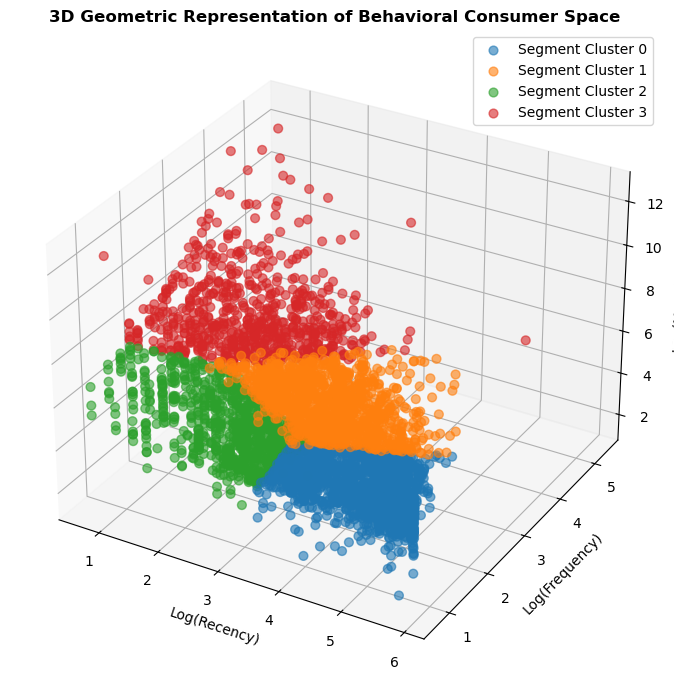

In [8]:
import seaborn as sns

# Calculate structural mean metrics across each customer group
cluster_summary = rfm_df.groupby('Cluster_ID').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

# Format table presentation layout
cluster_summary.columns = ['Avg_Recency_Days', 'Avg_Frequency_Orders', 'Avg_Monetary_Spend', 'Customer_Count']
cluster_summary = cluster_summary.reset_index()

print("\n📊 ENTERPRISE PROFILE INTERPRETATION MATRIX:\n")
print(cluster_summary.to_string(index=False))

# Build a visual 3D distribution breakdown chart
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = ['#1A365D', '#4A5568', '#E2E8F0', '#3182CE'] # Corporate cohesive layout palette

for cluster in range(optimal_k):
    subset = rfm_df[rfm_df['Cluster_ID'] == cluster]
    ax.scatter(np.log1p(subset['Recency']), 
               np.log1p(subset['Frequency']), 
               np.log1p(subset['Monetary']), 
               label=f'Segment Cluster {cluster}', 
               alpha=0.6, s=40)

ax.set_title('3D Geometric Representation of Behavioral Consumer Space', fontsize=12, fontweight='bold')
ax.set_xlabel('Log(Recency)')
ax.set_ylabel('Log(Frequency)')
ax.set_zlabel('Log(Monetary)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 8: Cluster Interpretation, Analytical Profiling, and Labeling

🏆 CORPORATE SEGMENTATION INTERPRETATION MATRIX:
------------------------------------------------------------------------------------------
 Cluster_ID  Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_Count          Segment_Name
          0        182.9            1.3         351.0            1617    Hibernating / Lost
          1         69.5            4.1        1819.7            1176  At-Risk / High-Spend
          2         18.4            2.1         544.4             840 New / Casual Shoppers
          3         11.9           13.8        8151.2             705    Whales / Champions
------------------------------------------------------------------------------------------


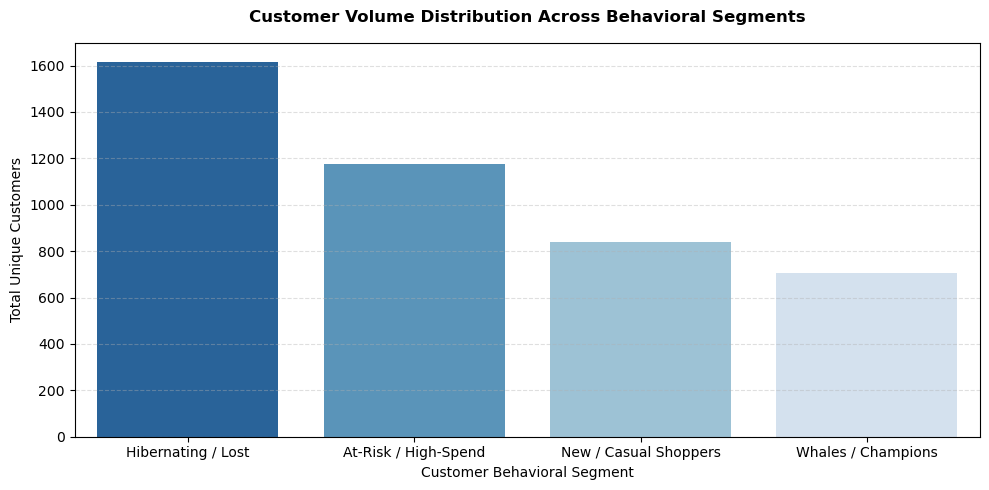

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compute the exact statistical means for each geometric cluster
cluster_profiles = rfm_df.groupby('Cluster_ID').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

cluster_profiles.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']
cluster_profiles = cluster_profiles.reset_index()

# 2. Dynamic Business Mapping Logic based on Centroid Positions
# We assign meaningful industry names based on their RFM positions
def assign_business_labels(row):
    # High frequency, high monetary, low recency -> Whales / Champions
    if row['Avg_Frequency'] > 5.0 and row['Avg_Monetary'] > 2000:
        return "Whales / Champions"
    # High recency, low frequency, low monetary -> Hibernating / Lost
    elif row['Avg_Recency'] > 150:
        return "Hibernating / Lost"
    # Low recency, low frequency -> New / Casual Customers
    elif row['Avg_Recency'] <= 50 and row['Avg_Frequency'] <= 2.5:
        return "New / Casual Shoppers"
    # Remaining fallback classification -> At-Risk / High-Value Spenders
    else:
        return "At-Risk / High-Spend"

# Apply business descriptions to the profiles
cluster_profiles['Segment_Name'] = cluster_profiles.apply(assign_business_labels, axis=1)

# Map names back into the primary master RFM dataframe for future querying
cluster_mapping = dict(zip(cluster_profiles['Cluster_ID'], cluster_profiles['Segment_Name']))
rfm_df['Segment'] = rfm_df['Cluster_ID'].map(cluster_mapping)

print("🏆 CORPORATE SEGMENTATION INTERPRETATION MATRIX:")
print("-" * 90)
print(cluster_profiles.to_string(index=False))
print("-" * 90)

# 3. Visualize Segment Distributions using a Categorical Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=cluster_profiles, x='Segment_Name', y='Customer_Count', palette='Blues_r', hue='Segment_Name', legend=False)
plt.title('Customer Volume Distribution Across Behavioral Segments', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Customer Behavioral Segment', fontsize=10)
plt.ylabel('Total Unique Customers', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# 9: Production-Grade Cluster Prediction Engine

In [10]:
def predict_customer_segment(raw_recency, raw_frequency, raw_monetary, original_scaler, trained_kmeans_model, label_dictionary):
    """
    Transforms raw customer metrics and infers their behavioral segment.
    
    Parameters:
    -----------
    raw_recency : float : Days since the customer's last purchase
    raw_frequency : int : Total number of unique orders placed
    raw_monetary : float : Total financial spend across their history
    original_scaler : StandardScaler : Fitted scaler instance from the training block
    trained_kmeans_model : KMeans : Fitted K-Means model instance
    label_dictionary : dict : Mapping dictionary linking Cluster IDs to Segment Name strings
    """
    # 1. Structural safety checks for geometric boundary inputs
    if raw_recency < 0 or raw_frequency <= 0 or raw_monetary <= 0:
        raise ValueError("❌ Invalid Input: Frequency and Monetary values must be strictly greater than zero.")
        
    # 2. Package raw observations into a structured dataframe matching scaler schema
    raw_input_data = pd.DataFrame([{
        'Recency': float(raw_recency),
        'Frequency': float(raw_frequency),
        'Monetary': float(raw_monetary)
    }])
    
    # 3. Apply the exact mathematical log-normalization transformation
    log_transformed_input = np.log1p(raw_input_data)
    
    # 4. Standardize spatial vectors using the checked training scaler properties
    standardized_vector = original_scaler.transform(log_transformed_input)
    
    # 5. Extract closest centroid geometric cluster classification label
    predicted_cluster_id = trained_kmeans_model.predict(standardized_vector)[0]
    corresponding_segment_name = label_dictionary[predicted_cluster_id]
    
    return {
        'Assigned_Cluster_ID': int(predicted_cluster_id),
        'Target_Segment_Label': corresponding_segment_name
    }

print("⚙️ Production Prediction Engine compiled successfully. Running simulation tests...")
print("=" * 70)

⚙️ Production Prediction Engine compiled successfully. Running simulation tests...


In [11]:
# Test Case A: Simulating a highly active, high-spending loyal customer
whale_test = predict_customer_segment(
    raw_recency=3,        # Purchased 3 days ago
    raw_frequency=15,     # 15 separate transactions
    raw_monetary=5200.50, # Spent over $5,200
    original_scaler=scaler,
    trained_kmeans_model=final_model,
    label_dictionary=cluster_mapping
)
print(f"👤 Test Case A (High Spender) -> Assigned to Cluster {whale_test['Assigned_Cluster_ID']}: {whale_test['Target_Segment_Label']}")

👤 Test Case A (High Spender) -> Assigned to Cluster 3: Whales / Champions


In [12]:
# Test Case B: Simulating a customer who hasn't purchased in a long time
churn_test = predict_customer_segment(
    raw_recency=280,      # Last purchase was 280 days ago
    raw_frequency=1,      # Only ordered once
    raw_monetary=35.00,   # Low spend
    original_scaler=scaler,
    trained_kmeans_model=final_model,
    label_dictionary=cluster_mapping
)
print(f"👤 Test Case B (Dormant User) -> Assigned to Cluster {churn_test['Assigned_Cluster_ID']}: {churn_test['Target_Segment_Label']}")
print("=" * 70)

👤 Test Case B (Dormant User) -> Assigned to Cluster 0: Hibernating / Lost
